# Compare ABL profiles

In [1]:
# Add any possible locations of amr-wind-frontend here
import sys, os
curdir = os.getcwd()
extradirs = ['../', '../../',
             os.path.dirname(curdir),
            ]
for x in extradirs: sys.path.insert(1, x)

import numpy as np
import matplotlib.pyplot as plt
import SANDwake3D_keps as SANDwake3D
import SANDwake3D_base as sdb

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from mpl_toolkits.axes_grid1 import make_axes_locatable
#?solve_ivp

## Set mesh and BC's 

In [3]:
# y-z mesh
dz   = 2
zmin = dz
zmax = 280
Nz   = int((zmax-zmin)/dz+1)
zvec = np.linspace(zmin,zmax,Nz)

dy   = 2
ymax = 100
Ny   = int((2*ymax)/dy+1)
yvec = np.linspace(-ymax,ymax,Ny)
#Ny=51
#ymax = 125
#yvec = np.linspace(-ymax,ymax,Ny)

In [4]:
ym, zm = np.meshgrid(yvec, zvec, indexing='ij')

dy   = np.mean(np.diff(yvec))
dz   = np.mean(np.diff(zvec))
print(f'dy = {dy}')
print(f'dz = {dz}')
print(ym.shape)

dy = 2.0
dz = 2.0
(101, 140)


In [5]:
turbhh = 90.0
rotorD = 127
turbR  = rotorD*0.5

# Set parameters
params = {
    'rho' : 1.225,
    'cp'  : 1005,
    'g'   : 9.81,
    'nu'  : 1.5E-5,
    'Cmu' : 5.48**(-2),
    'C1eps' : 1.76,
    'C2eps' : 1.92,
    'C3eps' : 0.033,
    'sigmak' : 1.0,
    'sigmaeps' : 1.3,
    'sigmaT':1.0,
    'dtau':1,
    
    'ustar' : 0.289, #0.4, #0.575652,
    'qw': 0.0,
    'L' : float('inf'),
    'kappa' : 0.42,
    'z0' : 0.01,

    'zlo':zmin,
    'Tw':300,
    'beta':1.0/300.0,
    'Tref':300,
    
    # Extra mesh variables needed for turbine forcing
    'ym':ym,
    'zm':zm,
    
    'XXXturbforcingXXX':{'turbx':400.0,     # Turbine x location
                   'turby':0.0,     # Turbine y location
                   'zhh':turbhh,      # Turbine hub-height
                   'turbD':rotorD,   # Turbine diameter
                   'Ct':0.8,
                   'Rdelta':0.5,
                   'turbfunc':sdb.tanhADM,
                  }
}

# This parameter defines V(z) -- m/s per meter
veerpermeter = 0.0 #0.02

In [6]:
# Set up ABL profile
UABL = np.zeros(Nz)
for iz, z in enumerate(zvec):
    UABL[iz] = SANDwake3D.init_U_ABL(z,params)
    
# Set up veer profile
veerV = np.zeros(Nz)
for i, z in enumerate(zvec):
    veerV[i] = veerpermeter*(z-turbhh)
    
# Compute the wind direction
ztop = turbhh + turbR
zbot = turbhh - turbR
Utop, Ubot = np.interp(ztop, zvec, UABL), np.interp(zbot, zvec, UABL)
Vtop, Vbot = np.interp(ztop, zvec, veerV), np.interp(zbot, zvec, veerV)
Wdirtop = np.arctan2(Vtop, Utop)*180/np.pi
Wdirbot = np.arctan2(Vbot, Ubot)*180/np.pi

Uhh, Vhh = np.interp(turbhh, zvec, UABL), np.interp(turbhh, zvec, UABL)
alpha = np.log(Utop/Ubot)/np.log(ztop/zbot)
print('Uhh = ',Uhh)
print('alpha = ',alpha)
print('rotor veer = ',Wdirtop-Wdirbot)

Uhh =  6.265093282085727
alpha =  0.1145689710703235
rotor veer =  0.0


In [7]:
Uinit  = np.zeros((Ny, Nz))
Vinit  = np.zeros((Ny, Nz))
Winit  = np.zeros((Ny, Nz))
Kinit  = np.zeros((Ny, Nz))
Tinit  = np.ones((Ny, Nz))*params['Tref']
EPSinit= np.zeros((Ny, Nz))
pinit  = np.zeros((Ny, Nz))

for iz, z in enumerate(zvec):
    Uinit[:, iz] = UABL[iz] #SANDwake3D.init_U_ABL(z,ABLparam)
    Vinit[:, iz] = veerV[iz]
    Winit[:, iz] = 0.0
    #Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,ABLparam)
    Kinit[:, iz]   = SANDwake3D.init_k_ABL(z,params)*np.exp(-0.002*z)
    #EPSinit[:, iz] = 5.0E-3 #9.75E-4 #5.0E-4 #SANDwake3D.init_e_ABL(z,ABLparam)*0.1  #5.0E-4 is good
    EPSinit[:, iz] = SANDwake3D.init_e_ABL(z,params)
    
phiinit = {}
phiinit['u'] = Uinit
phiinit['v'] = Vinit
phiinit['w'] = Winit
phiinit['k'] = Kinit
phiinit['T'] = Tinit
phiinit['eps'] = EPSinit
phiinit['p'] = pinit

(0.0, 280.0)

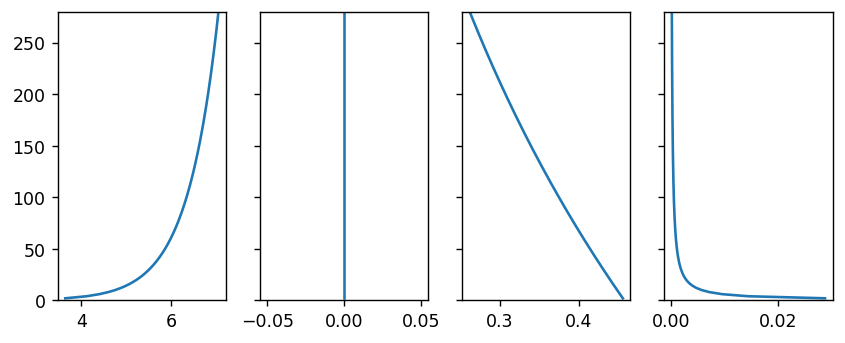

In [8]:
fig, axs = plt.subplots(1,4, sharey=True, dpi=125, figsize=(8,3))
axs[0].plot(Uinit[Ny//2,:], zvec)
axs[1].plot(Vinit[Ny//2,:], zvec)
axs[2].plot(Kinit[Ny//2,:], zvec)
axs[3].plot(EPSinit[Ny//2,:], zvec)
axs[0].set_ylim([0, zmax])

In [9]:
xvecplot=[0, 600, 1000]
dx  = 150

xvec = np.arange(xvecplot[0], xvecplot[-1]+1.0E-6, dx)
#xvec=[0, 200, 400, 600]

#xvec = xvecplot
start_time = time.time()
phi = SANDwake3D.marchSystem(phiinit, xvec, dy, dz, params, 
                             SANDwake3D.getTypicalWMBC(Uinit[0,-1], params['Tw'], veerBC=veerV),
                             SANDwake3D.kepsT_eqns, 
                             advanceSys=SANDwake3D.advanceSystemKEPS,
                             verbose=True, maxiter=100, tol=1.0E-4)
end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time: {execution_time:.4f} seconds")

x = 150.0 dx = 150.0
[0] u: 7.0589e+00, w: 0.0000e+00, k: 1.5691e+00, eps: 1.3188e-01, T: 4.7375e-11, v: 0.0000e+00, p: 0.0000e+00
[1] u: 3.9032e+00, w: 1.0913e-11, k: 1.5504e+00, eps: 1.1077e-01, T: 6.5485e-11, v: 0.0000e+00, p: 5.8069e-04
[2] u: 2.1792e+00, w: 9.2443e-04, k: 1.9815e+00, eps: 1.2794e-01, T: 6.0722e-11, v: 4.7775e-05, p: 2.5881e-04
[3] u: 1.1465e+00, w: 4.1189e-04, k: 1.9123e+00, eps: 1.0352e-01, T: 6.0128e-11, v: 3.9767e-05, p: 3.4598e-04
[4] u: 4.1083e-01, w: 5.6062e-04, k: 1.3821e+00, eps: 6.1080e-02, T: 4.8981e-11, v: 4.4419e-05, p: 2.6917e-04
[5] u: 2.8722e-01, w: 4.0606e-04, k: 6.6867e-01, eps: 2.4002e-02, T: 5.4187e-11, v: 3.3191e-05, p: 2.1327e-04
[6] u: 2.6258e-01, w: 3.3971e-04, k: 2.4467e-01, eps: 8.3983e-03, T: 5.6347e-11, v: 2.0482e-05, p: 9.8002e-05
[7] u: 1.8533e-01, w: 1.6983e-04, k: 1.5168e-01, eps: 1.0409e-02, T: 5.1404e-11, v: 7.2954e-06, p: 5.3410e-05
[8] u: 8.9420e-02, w: 1.0243e-04, k: 1.5997e-01, eps: 8.9422e-03, T: 4.4179e-11, v: 4.2668e-06, p: 

(2.0, 280.0)

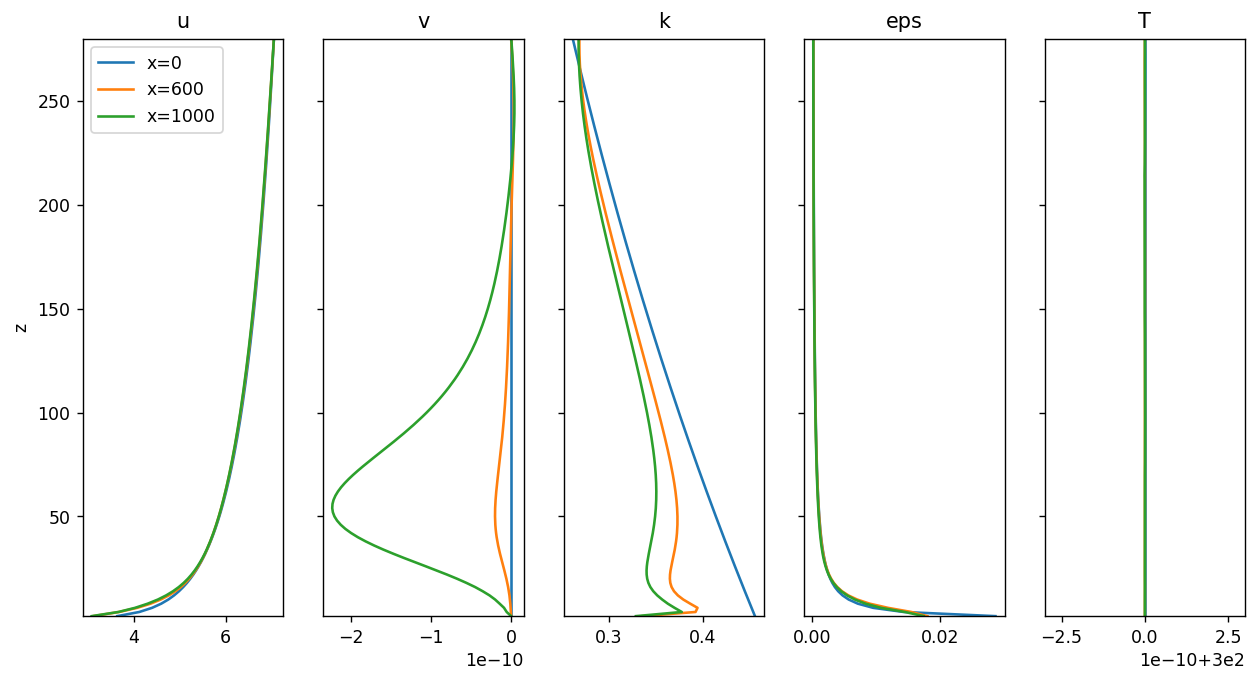

In [10]:
plotvars=['u', 'v', 'k', 'eps', 'T']
find_nearest = lambda a, a0: np.abs(np.array(a) - a0).argmin()
islice = find_nearest(yvec, 0)# Ny//2

#xvecplot=[0, 50]

fig, axs = plt.subplots(1,len(plotvars),figsize=(12,6), dpi=125, sharey=True)
for iv, v in enumerate(plotvars):
    for x in xvecplot:
        ixRANS = find_nearest(xvec, x)
        axs[iv].plot(phi[v][ixRANS,islice,:], zvec, label='x=%.0f'%x)
    axs[iv].set_title(v)
    
axs[0].legend()
axs[0].set_ylabel('z')
axs[0].set_ylim([zmin, zmax])

## Plot lidar data

In [11]:
def plotrotorlines(zhh, rotorD, xstart, xend, **kwargs):
    plt.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) # Plot the HH line
    plt.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line
    plt.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line   

def plotrotorlinesax(ax, zhh, rotorD, xstart, xend, **kwargs):
    ax.hlines(zhh,             xstart, xend, linewidth=1.0, **kwargs) # Plot the HH line
    ax.hlines(zhh+rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line
    ax.hlines(zhh-rotorD*0.5,  xstart, xend, linewidth=0.5, **kwargs) # Plot the HH line   

In [12]:
# Put the list of all cases in here
cases = [
    # AMR-Wind data defs
    {'label':'AMR-Wind',
     #'datadir':'../AMR.5kmX5km_noturbine1/post_processing/data_noturb',
     'datadir':'./',
     'prefix':'AMRWIND',
     'fname':'{prefix}_InflowProfiles_noturbine_x_-2.0D.dat',
     'linestyle':{'linestyle':'-', 'lw':2},
    },
        
]

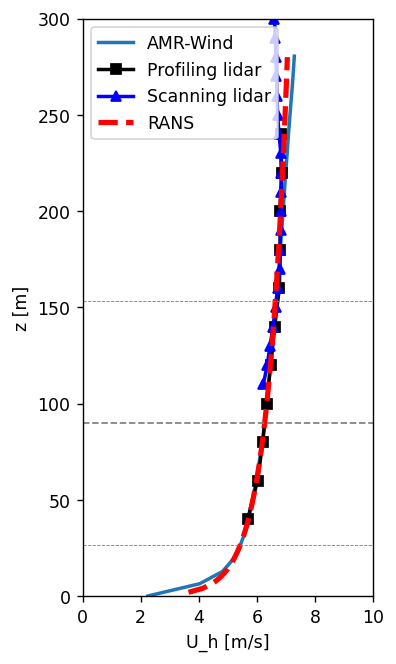

In [13]:
lidardir='./'

# Plot wind speed
WS_profiling = np.loadtxt(lidardir+'/Profiles_WindSpeed_a1_selectedcase_profiling.txt',delimiter=',')
WS_scanning  = np.loadtxt(lidardir+'/Profiles_WindSpeed_a1_selectedcase_scanning.txt',delimiter=',') 

fig, ax = plt.subplots(1,1, figsize=(3,6), dpi=125)
for icase, case in enumerate(cases):
    label   = case['label']
    prefix  = case['prefix']
    datadir = case['datadir']
    fname   = case['fname'] 
    lstyle  = case['linestyle']
    dat=np.loadtxt(datadir+'/'+fname.format(prefix=prefix))
    z  = dat[:,0]
    uh = dat[:,1]
    ax.plot(uh, z,  label=label, **lstyle)

# Plot lidar data
ax.plot(WS_profiling[:,0], WS_profiling[:,1], 'k-', marker='s', label='Profiling lidar', lw=2)
ax.plot(WS_scanning[:,0],  WS_scanning[:,1],  'b-', marker='^', label='Scanning lidar', lw=2)

ax.plot(phi['u'][0,islice,:], zvec, 'r--', lw=3, label='RANS')

# Plot the turbine dimensions
plotrotorlines(turbhh, rotorD, 0, 20, linestyles='dashed', color='gray',)

ax.set_ylim([0,300])
ax.set_xlim([0, 10])
ax.set_ylabel('z [m]')
ax.set_xlabel('U_h [m/s]')
ax.legend(loc='upper left')

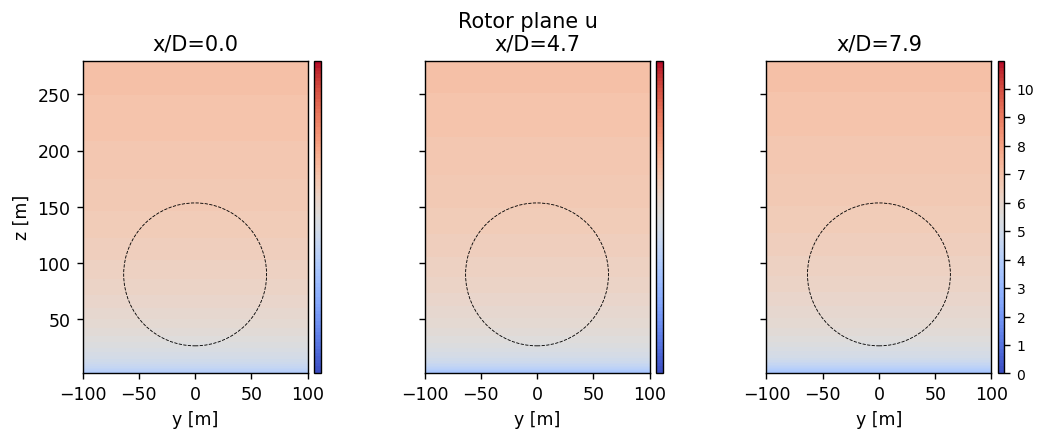

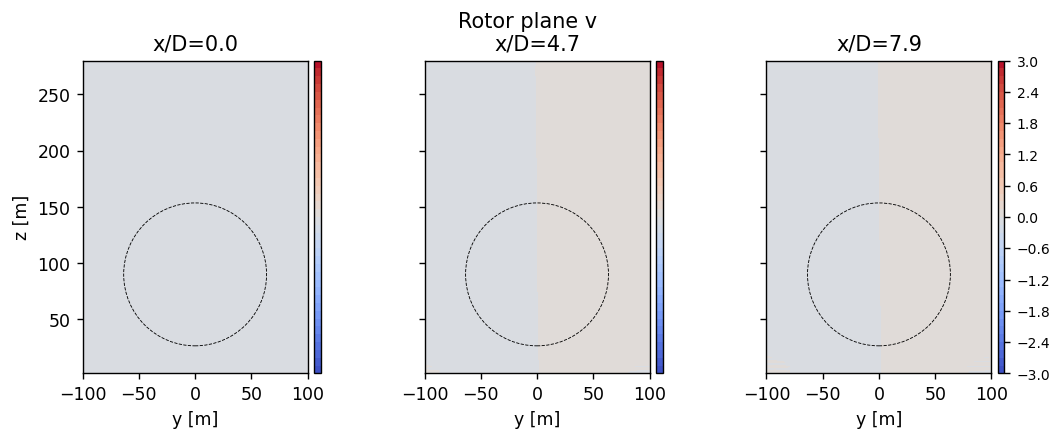

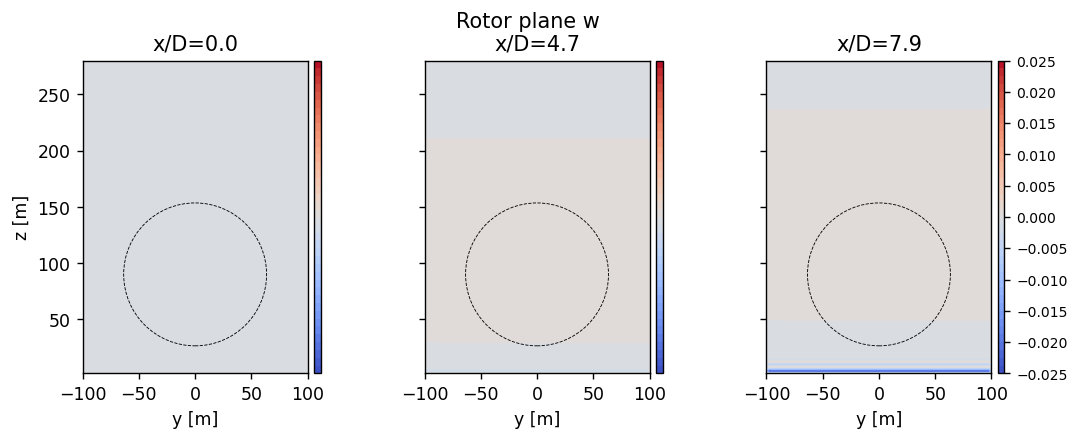

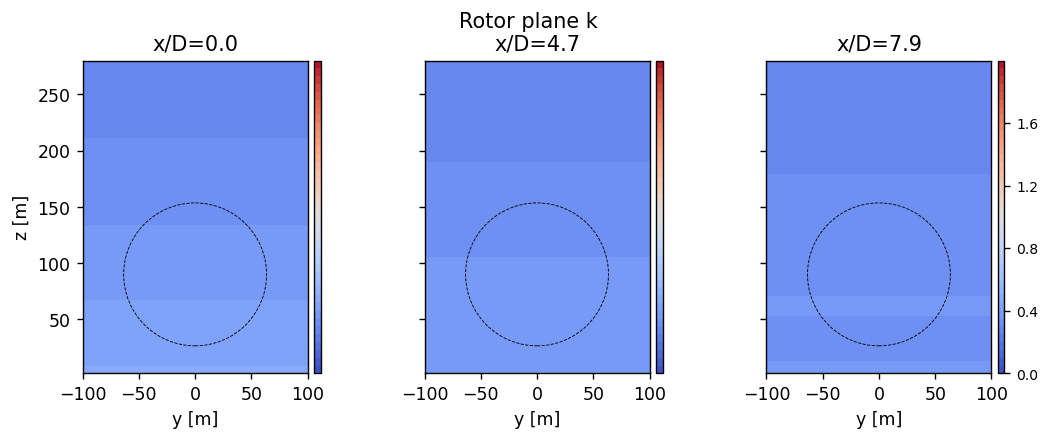

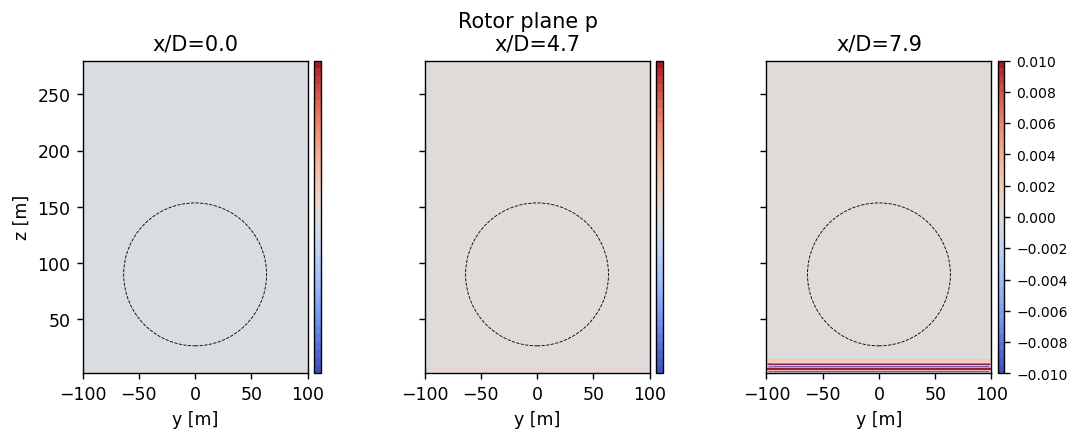

In [14]:
savefigs = False
cbarticks=np.arange(0,11,1)
plotvars=['u','v', 'w', 'k', 'p']
maxV=3
maxL=0.025
maxP=0.01
vlevels={'u':{'levels':np.linspace(0,11,91), 'cbarticks':np.arange(0,11,1)},
         'v':{'levels':np.linspace(-maxV,maxV,41), 'cbarticks':np.arange(-maxV, maxV+1E-5,maxV/5)},
         'w':{'levels':np.linspace(-maxL,maxL,41), 'cbarticks':np.arange(-maxL, maxL+1E-5,maxL/5)}, 
         'k':{'levels':np.linspace(0,2,41), 'cbarticks':np.arange(0, 2,2.0/5)}, 
         'p':{'levels':np.linspace(-maxP,maxP,41), 'cbarticks':np.arange(-maxP, maxP+1E-5,maxP/5)}, 
        }

for plotv in plotvars:
    fig, axs = plt.subplots(1, len(xvecplot), figsize=(10,3.25), dpi=125, sharey=True)
    for ix, x in enumerate(xvecplot):
        ixRANS = find_nearest(xvec, x)
        c=axs[ix].contourf(ym, zm, phi[plotv][ixRANS,:,:], levels=vlevels[plotv]['levels'], cmap='coolwarm')
        axs[ix].set_aspect('equal')
        axs[ix].set_title('x/D=%.1f'%(0.5*x/turbR))
        axs[ix].set_xlabel('y [m]')
        rotorcirc = plt.Circle((0.0, turbhh), turbR, color='k', linestyle='--', lw=0.5, fill=False)
        axs[ix].add_patch(rotorcirc)
    
        divider = make_axes_locatable(axs[ix])
        cax = divider.append_axes("right", size="3%", pad=0.05)
        if ix < len(xvecplot)-1:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator([]))
        else:
            cbar=fig.colorbar(c, ax=axs[ix], cax=cax, ticks = matplotlib.ticker.FixedLocator(vlevels[plotv]['cbarticks']))
            cbar.ax.tick_params(labelsize=8)
        
    axs[0].set_ylabel('z [m]')
    plt.suptitle('Rotor plane '+plotv,y=1.0)

if savefigs:
    plt.tight_layout()
    plt.savefig('TestABL_KEPST.png')